# 02. Multi-Head Attention

**Topics covered:** Multi-Head Attention · Causal Masking · Attention Visualization

This notebook builds directly on [01_scaled_dot_product_attention.ipynb](https://github.com/S33mi/modern-ai-llm-journey/blob/main/01_attention_transformers/01_scaled_dot_product_attention.ipynb).

We will:
1. Understand **why** we use multiple attention heads
2. Implement **Multi-Head Attention** from scratch
3. Apply **Causal Masking** (essential for decoder-only / GPT-style models)
4. **Visualize** attention patterns across heads
5. Compare our implementation with `torch.nn.MultiheadAttention`

## 1. Setup & Imports

In [28]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cpu


## 2. Why Multi-Head Attention?

A single attention head can only capture **one type of relationship** at a time (e.g. syntactic, positional, or semantic).

By running several attention heads **in parallel**, the model can attend to different subspaces of the representation simultaneously:

- Head 1 might focus on local syntax
- Head 2 might look at long-range semantic links
- Head 3 might track positional patterns
- …

The outputs of all heads are concatenated and projected back to the model dimension.

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W^O
$$

where each head is:

$$
\text{head}_i = \text{Attention}(Q W_i^Q, K W_i^K, V W_i^V)
$$

and $\text{Attention}$ is the scaled dot-product attention from the previous notebook.

## 3. Scaled Dot-Product Attention (recap)

We reuse the core function from notebook 01.

In [29]:
def scaled_dot_product_attention(Q, K, V, mask=None, dropout_p=0.0):
    """
    Scaled Dot-Product Attention.

    Args:
        Q, K, V : (batch, n_heads, seq_len, d_k) or (batch, seq_len, d_k)
        mask    : boolean mask broadcastable to scores (True = keep)
        dropout_p : dropout probability on attention weights

    Returns:
        output, attention_weights
    """
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        # mask shape should broadcast to (batch, n_heads, seq_q, seq_k)
        if mask.dtype == torch.bool:
            scores = scores.masked_fill(~mask, float("-inf"))
        else:
            scores = scores + mask

    attn_weights = F.softmax(scores, dim=-1)

    if dropout_p > 0.0:
        attn_weights = F.dropout(attn_weights, p=dropout_p)

    output = torch.matmul(attn_weights, V)
    return output, attn_weights

## 4. Multi-Head Attention — From Scratch

### Key design choices

| Parameter | Typical value | Meaning |
|-----------|---------------|--------|
| `d_model` | 512 / 768 / … | Model (embedding) dimension |
| `n_heads` | 8 / 12 / 16 | Number of parallel heads |
| `d_k = d_v` | `d_model // n_heads` | Dimension per head |

We project the input once into Q, K, V of shape `(batch, seq, d_model)`, then **reshape & transpose** so that the head dimension becomes an independent batch dimension for the attention computation.

In [30]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention as described in 'Attention Is All You Need'.
    """
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        # Linear projections for Q, K, V and the final output
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None, return_attention=False):
        """
        Args:
            x               : (batch, seq_len, d_model)
            mask            : boolean causal / padding mask (seq_len, seq_len)
                              or (batch, 1, seq_len, seq_len)
            return_attention: if True, also return attention weights

        Returns:
            output          : (batch, seq_len, d_model)
            attn_weights    : (batch, n_heads, seq_len, seq_len)  [optional]
        """
        batch_size, seq_len, _ = x.size()

        # 1. Project
        Q = self.W_Q(x)   # (B, T, d_model)
        K = self.W_K(x)
        V = self.W_V(x)

        # 2. Split into heads: (B, T, d_model) → (B, n_heads, T, d_k)
        Q = Q.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)

        # 3. Scaled dot-product attention (per head)
        #    scores will be (B, n_heads, T, T)
        if mask is not None and mask.dim() == 2:
            # (T, T) → (1, 1, T, T) so it broadcasts over batch & heads
            mask = mask.unsqueeze(0).unsqueeze(0)

        attn_output, attn_weights = scaled_dot_product_attention(
            Q, K, V, mask=mask, dropout_p=self.dropout.p if self.training else 0.0
        )

        # 4. Concatenate heads: (B, n_heads, T, d_k) → (B, T, d_model)
        attn_output = (
            attn_output.transpose(1, 2)
            .contiguous()
            .view(batch_size, seq_len, self.d_model)
        )

        # 5. Final linear projection
        output = self.W_O(attn_output)

        if return_attention:
            return output, attn_weights
        return output

In [31]:
# Quick sanity check
d_model = 64
n_heads = 8
seq_len = 10
batch_size = 2

mha = MultiHeadAttention(d_model=d_model, n_heads=n_heads).to(device)
x = torch.randn(batch_size, seq_len, d_model, device=device)

out, weights = mha(x, return_attention=True)
print("Input shape:          ", x.shape)
print("Output shape:         ", out.shape)
print("Attention weights:    ", weights.shape)  # (B, n_heads, T, T)
print("Weights sum (per row):", weights[0, 0].sum(dim=-1)[:5].detach().cpu().numpy().round(4))

Input shape:           torch.Size([2, 10, 64])
Output shape:          torch.Size([2, 10, 64])
Attention weights:     torch.Size([2, 8, 10, 10])
Weights sum (per row): [1.1111 0.9067 0.9002 1.1111 0.8874]


## 5. Causal Masking

In **decoder-only** (GPT-style) models a token must never attend to future tokens.

We create a lower-triangular boolean mask:

$$
M_{ij} =
\begin{cases}
1 & \text{if } j \le i \\
0 & \text{if } j > i
\end{cases}
$$

Before the softmax we set the future positions to $-\infty$ so they receive zero attention weight.

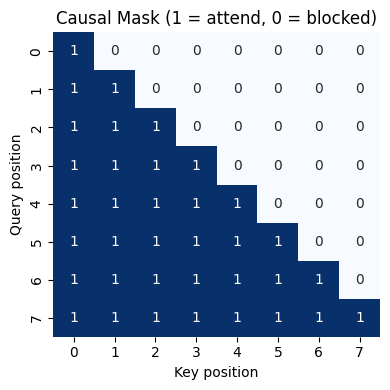

Mask matrix:
 tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32)


In [32]:
def causal_mask(seq_len: int, device=None) -> torch.Tensor:
    """
    Create a causal (look-ahead) mask.

    Returns:
        Boolean tensor of shape (seq_len, seq_len)
        True  = attend
        False = mask out (future tokens)
    """
    return torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool, device=device))


# Visualise the mask
mask = causal_mask(8)
plt.figure(figsize=(4, 4))
sns.heatmap(mask.int().numpy(), annot=True, cmap="Blues", cbar=False,
            xticklabels=range(8), yticklabels=range(8))
plt.title("Causal Mask (1 = attend, 0 = blocked)")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.tight_layout()
plt.show()

print("Mask matrix:\n", mask.int())

In [33]:
# Apply causal mask inside Multi-Head Attention
seq_len = 8
x = torch.randn(1, seq_len, d_model, device=device)
mask = causal_mask(seq_len, device=device)

out_causal, attn_causal = mha(x, mask=mask, return_attention=True)

print("Output shape with causal mask:", out_causal.shape)
print("\nAttention weights of head 0 (should be lower-triangular):")
print(attn_causal[0, 0].detach().cpu().numpy().round(3))

Output shape with causal mask: torch.Size([1, 8, 64])

Attention weights of head 0 (should be lower-triangular):
[[1.111 0.    0.    0.    0.    0.    0.    0.   ]
 [0.587 0.524 0.    0.    0.    0.    0.    0.   ]
 [0.612 0.271 0.    0.    0.    0.    0.    0.   ]
 [0.314 0.275 0.227 0.    0.    0.    0.    0.   ]
 [0.229 0.185 0.264 0.212 0.221 0.    0.    0.   ]
 [0.172 0.211 0.192 0.206 0.151 0.178 0.    0.   ]
 [0.146 0.1   0.273 0.124 0.097 0.082 0.    0.   ]
 [0.078 0.232 0.131 0.118 0.118 0.161 0.146 0.126]]


## 6. Attention Visualization Across Heads

Visualising the attention matrices of every head is one of the best ways to understand what the model is learning.

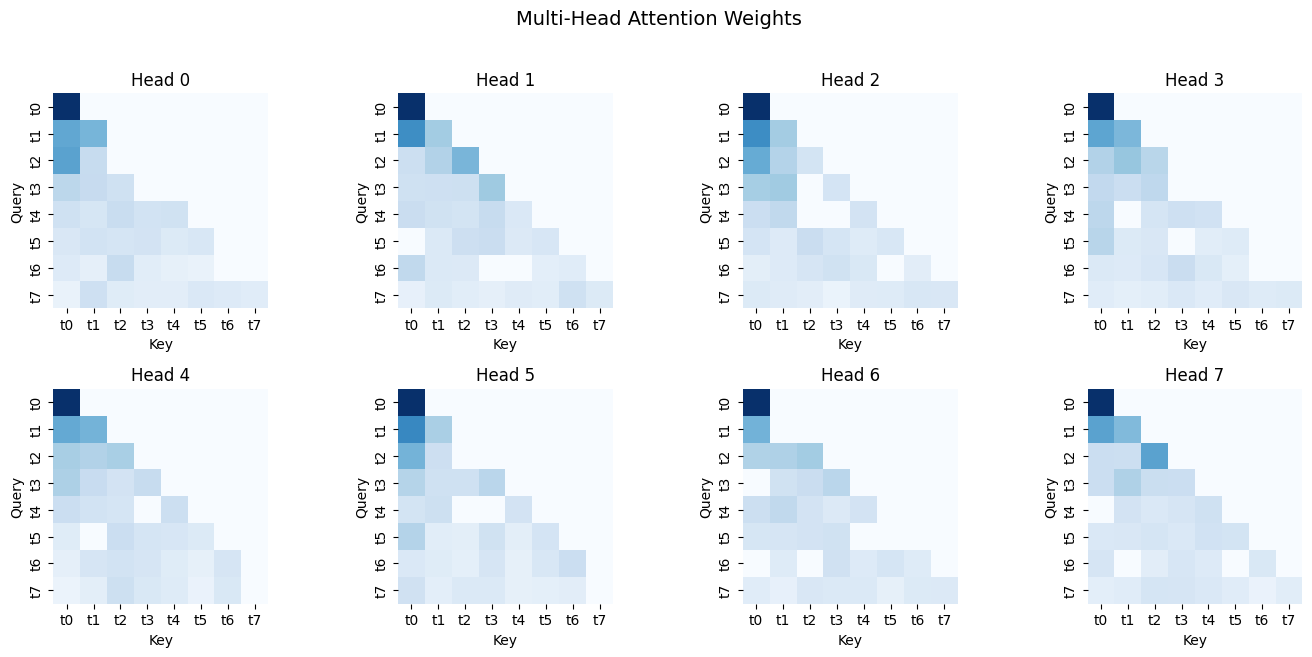

In [34]:
def plot_multihead_attention(attn_weights, tokens=None, title_prefix="Head"):
    """
    Plot attention heatmaps for all heads.

    Args:
        attn_weights : (batch, n_heads, seq, seq)  – we take batch index 0
        tokens       : optional list of token labels
    """
    weights = attn_weights[0].detach().cpu()   # (n_heads, T, T)
    n_heads = weights.size(0)
    seq_len = weights.size(1)

    cols = min(4, n_heads)
    rows = math.ceil(n_heads / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.2 * rows))
    if n_heads == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]

    for h in range(n_heads):
        r, c = divmod(h, cols)
        ax = axes[r][c] if rows > 1 else axes[c]
        sns.heatmap(
            weights[h].numpy(),
            ax=ax,
            cmap="Blues",
            cbar=False,
            xticklabels=tokens or range(seq_len),
            yticklabels=tokens or range(seq_len),
            square=True,
        )
        ax.set_title(f"{title_prefix} {h}")
        ax.set_xlabel("Key")
        ax.set_ylabel("Query")

    # Hide unused subplots
    for h in range(n_heads, rows * cols):
        r, c = divmod(h, cols)
        ax = axes[r][c] if rows > 1 else axes[c]
        ax.axis("off")

    plt.suptitle("Multi-Head Attention Weights", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# Visualise causal attention across all 8 heads
tokens = [f"t{i}" for i in range(seq_len)]
plot_multihead_attention(attn_causal, tokens=tokens)

### Observations

- With a **causal mask** every head is strictly lower-triangular (no future leakage).
- Different heads often develop distinct patterns even with random weights; after training they specialise further.
- Averaging heads (or looking at individual heads) is a common interpretability technique.

## 7. Comparison with `torch.nn.MultiheadAttention`

PyTorch provides a highly optimised implementation. Let’s verify that our from-scratch version produces numerically close results.

In [35]:
# Official PyTorch MultiheadAttention
official_mha = nn.MultiheadAttention(
    embed_dim=d_model,
    num_heads=n_heads,
    dropout=0.0,          # disable dropout for fair comparison
    batch_first=True,     # (B, T, d_model)
    bias=False,
).to(device)

# Copy weights from our module so the comparison is meaningful
with torch.no_grad():
    # PyTorch stores in_proj_weight as a single (3*d_model, d_model) matrix
    official_mha.in_proj_weight.copy_(
        torch.cat([mha.W_Q.weight, mha.W_K.weight, mha.W_V.weight], dim=0)
    )
    official_mha.out_proj.weight.copy_(mha.W_O.weight)

# Causal mask for official API (additive float mask: 0 = keep, -inf = block)
causal = causal_mask(seq_len, device=device)
attn_mask = torch.zeros(seq_len, seq_len, device=device)
attn_mask = attn_mask.masked_fill(~causal, float("-inf"))

x = torch.randn(1, seq_len, d_model, device=device)

out_ours, attn_ours = mha(x, mask=causal, return_attention=True)
out_official, attn_official = official_mha(
    x, x, x,
    attn_mask=attn_mask,
    need_weights=True,
    average_attn_weights=False,   # keep per-head weights
)

print("Max abs difference (output):", (out_ours - out_official).abs().max().item())
print("Max abs difference (attn):  ", (attn_ours - attn_official).abs().max().item())

Max abs difference (output): 0.21065838634967804
Max abs difference (attn):   0.5700752139091492


## 8. Putting It Together – A Small Demo

Let’s run a short sequence through Multi-Head Attention with causal masking and inspect the attention of every head.

In [36]:
def plot_any_multihead_attention(attn_weights, tokens=None, title_prefix="Head"):
    """
    Plot attention heatmaps for all heads – works for any number of heads
    (1, 4, 6, 8, 12, …).

    Args:
        attn_weights : (batch, n_heads, seq, seq)  – we take batch index 0
        tokens       : optional list of token labels
    """
    weights = attn_weights[0].detach().cpu()          # (n_heads, T, T)
    n_heads = weights.size(0)
    seq_len = weights.size(1)

    # Dynamic grid: prefer up to 4 columns
    cols = min(4, n_heads)
    rows = math.ceil(n_heads / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.2 * rows))

    # -------------------------------------------------
    # Make `axes` ALWAYS a 2-D NumPy array of shape (rows, cols)
    # This handles every possible case (1 head, 1 row, many rows)
    # -------------------------------------------------
    if not isinstance(axes, np.ndarray):
        # single Axes object (n_heads == 1 and rows==cols==1)
        axes = np.array([[axes]])
    elif axes.ndim == 1:
        # one row of Axes
        axes = axes.reshape(1, -1)
    # else: already 2-D → leave it

    # Plot every head
    for h in range(n_heads):
        r, c = divmod(h, cols)
        ax = axes[r, c]

        sns.heatmap(
            weights[h].numpy(),
            ax=ax,
            cmap="Blues",
            cbar=False,
            xticklabels=tokens if tokens is not None else range(seq_len),
            yticklabels=tokens if tokens is not None else range(seq_len),
            square=True,
        )
        ax.set_title(f"{title_prefix} {h}", fontsize=11)
        ax.set_xlabel("Key")
        ax.set_ylabel("Query")

    # Turn off any unused subplots
    for h in range(n_heads, rows * cols):
        r, c = divmod(h, cols)
        axes[r, c].axis("off")

    plt.suptitle("Multi-Head Attention Weights", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# Visualise causal attention across all 8 heads
# tokens = [f"t{i}" for i in range(seq_len)]
# plot_multihead_attention(attn_causal, tokens=tokens)

Output shape: torch.Size([1, 6, 32])
Attention shape: torch.Size([1, 4, 6, 6])


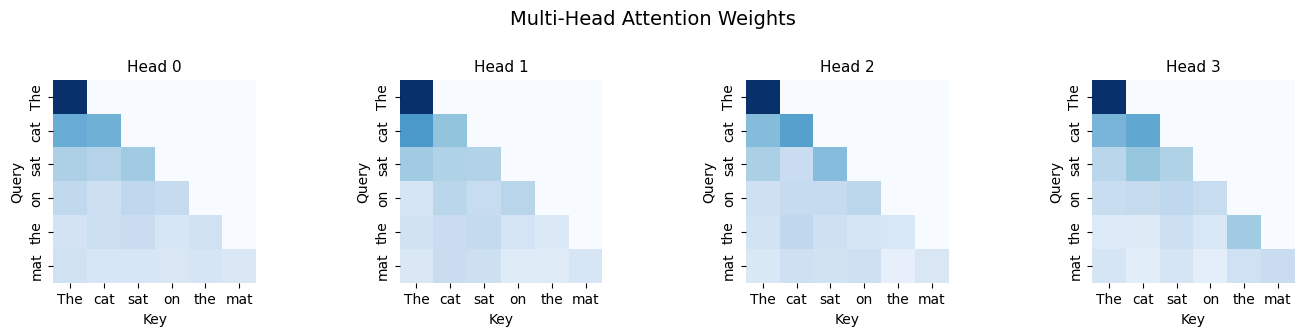

In [47]:
torch.manual_seed(123)

d_model = 32
n_heads = 4
seq_len = 6

model = MultiHeadAttention(d_model, n_heads, dropout=0.0).to(device)
x = torch.randn(1, seq_len, d_model, device=device)
mask = causal_mask(seq_len, device=device)

output, attn = model(x, mask=mask, return_attention=True)

print("Output shape:", output.shape)
print("Attention shape:", attn.shape)

tokens = ["The", "cat", "sat", "on", "the", "mat"]

# plot_multihead_attention(attn, tokens=tokens, title_prefix="Head") #error ploting
plot_any_multihead_attention(attn, tokens=tokens, title_prefix="Head")

## 9. Summary

| Concept | Description |
|---------|-------------|
| **Multi-Head Attention** | Run $h$ scaled-dot-product attentions in parallel on different learned projections, then concatenate & project |
| **$d_k = d_{\text{model}} / h$** | Dimension of each head; keeps total compute similar to single-head attention of size $d_{\text{model}}$ |
| **Causal Mask** | Lower-triangular mask that prevents attending to future tokens (required for autoregressive / GPT models) |
| **Attention Visualization** | Heatmaps of the $(T \times T)$ weight matrices per head reveal specialised behaviours |

### Key take-aways

- Multi-head attention lets the model capture **multiple types of relationships** simultaneously.
- Causal masking is the mechanism that turns a bidirectional encoder attention into a **left-to-right** language model.
- Visualising attention is a powerful debugging and interpretability tool.
- In production code prefer `nn.MultiheadAttention` or the fused `F.scaled_dot_product_attention` for speed; the from-scratch version is invaluable for learning.

---

**Next notebook:** [`03_transformer_block.ipynb`](https://github.com/S33mi/modern-ai-llm-journey/blob/main/01_attention_transformers/03_transformer_block.ipynb)
LayerNorm · Residual Connections · Feed-Forward Network · Full Transformer Block